# Task:2

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset

In [4]:
df = pd.read_csv('loan_prediction.csv')

In [3]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


##  Handle missing data appropriately

In [6]:
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].mean())
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df = df.ffill()  # Modern replacement for method='ffill'

In [46]:
df['Dependents'] = df['Dependents'].replace('3+', '3')
df['Dependents'] = pd.to_numeric(df['Dependents'])


##  Visualize key features

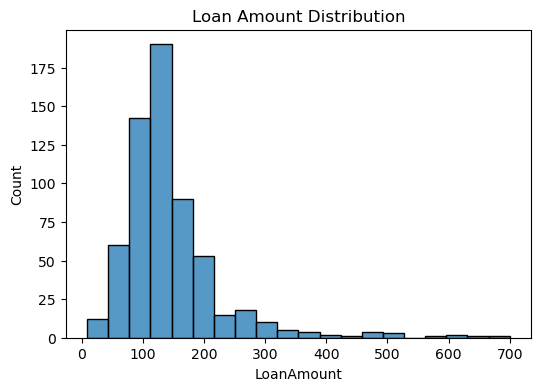

In [47]:
plt.figure(figsize=(6, 4))
sns.histplot(df['LoanAmount'], bins=20)
plt.title("Loan Amount Distribution")
plt.show()

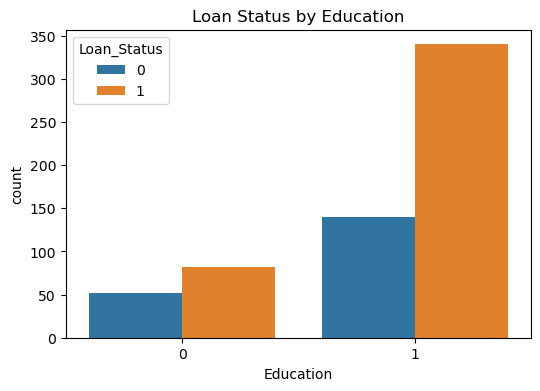

In [48]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Education', data=df, hue='Loan_Status')
plt.title("Loan Status by Education")
plt.show()

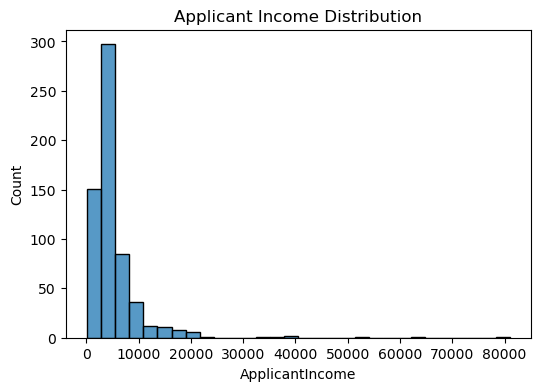

In [49]:
plt.figure(figsize=(6, 4))
sns.histplot(df['ApplicantIncome'], bins=30)
plt.title("Applicant Income Distribution")
plt.show()

## data_encoding

In [11]:
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['Married'] = df['Married'].map({'Yes': 1, 'No': 0})
df['Education'] = df['Education'].map({'Graduate': 1, 'Not Graduate': 0})
df['Self_Employed'] = df['Self_Employed'].map({'Yes': 1, 'No': 0})
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Scale features

In [50]:
X = df[['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 
        'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 
        'Loan_Amount_Term', 'Credit_History']]
y = df['Loan_Status']

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  #
)

## Train classification model

In [52]:
model = DecisionTreeClassifier(
    max_depth=5, 
    min_samples_split=20, 
    class_weight='balanced', 
    random_state=42
)
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,20
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [53]:
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7886178861788617
Confusion Matrix:
 [[23 15]
 [11 74]]

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.61      0.64        38
           1       0.83      0.87      0.85        85

    accuracy                           0.79       123
   macro avg       0.75      0.74      0.74       123
weighted avg       0.78      0.79      0.79       123




Top Features:
              Feature  Importance
9     Credit_History    0.531495
6  CoapplicantIncome    0.243766
5    ApplicantIncome    0.114935
7         LoanAmount    0.108735
8   Loan_Amount_Term    0.001069
